# 🛰️ ADCS Simulation – Main Notebook

This notebook controls the full simulation process of an Attitude Determination and Control System (ADCS) for a satellite.  
It ties together all the individual modules and provides plots and insights from the simulation results.

---

## 📂 Project Structure Overview

adcs_sim/  
│  
├── main_simulation.ipynb---# Main simulation controller and visualizer  
│  
├── config.py-----------------# Configuration for satellite, orbit, controller  
├── simulation.py------------# Main simulation loop  
│  
├── orbit.py------------------# Orbital motion model  
├── magnetic_field.py-------# Earth's magnetic field model  
├── attitude.py--------------# Attitude dynamics and kinematics  
├── sensors.py---------------# Simulated gyroscope and magnetometer data  
├── controllers.py-----------# ADCS control algorithms (e.g., B-dot)  
├── filters.py----------------# Orientation filters (e.g., complementary, Kalman)  
└── utils.py------------------# Helper functions and coordinate conversions


---

## 📌 Notebook Responsibilities

- Load configuration parameters from `config.py`
- Initialize satellite orbit, orientation, and sensor models
- Execute the simulation loop (`simulation.py`)
- Run control algorithms (e.g., `B-dot` from `controllers.py`)
- Visualize the results (attitude, angular velocity, control actions, etc.)

---

✅ Use this notebook as the **main entry point** for testing different control laws, noise conditions, and filtering techniques.


In [1]:
from sim import simulate
from config import SIMULATION_TIME, SIMULATION_TIMESTEP
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # potrzebne dla 3D

In [2]:
# Run main sim
times, positions, velocities, quaternions, omegas = simulate(SIMULATION_TIME, SIMULATION_TIMESTEP)

In [5]:
positions

[[6786.137, 0, 0],
 array([6785.70422897,   47.60398193,   60.06127747]),
 array([6784.40597108,   95.20189218,  120.11489439]),
 array([6782.24239192,  142.78765985,  180.15319118]),
 array([6779.21376743,  190.35521557,  240.16851021]),
 array([6775.32048392,  237.89849232,  300.15319681]),
 array([6770.56303794,  285.41142616,  360.09960018]),
 array([6764.94203629,  332.88795702,  420.00007442]),
 array([6758.4581959 ,  380.32202949,  479.84697949]),
 array([6751.11234376,  427.70759354,  539.63268218]),
 array([6742.90541679,  475.03860536,  599.34955709]),
 array([6733.83846175,  522.30902808,  658.98998758]),
 array([6723.91263509,  569.51283258,  718.54636678]),
 array([6713.12920281,  616.6439982 ,  778.01109854]),
 array([6701.48954027,  663.69651358,  837.37659839]),
 array([6688.99513207,  710.66437738,  896.63529451]),
 array([6675.64757181,  757.54159904,  955.77962873]),
 array([6661.4485619 ,  804.32219959, 1014.80205744]),
 array([6646.39991338,  851.00021236, 1073.695

TypeError: list indices must be integers or slices, not tuple

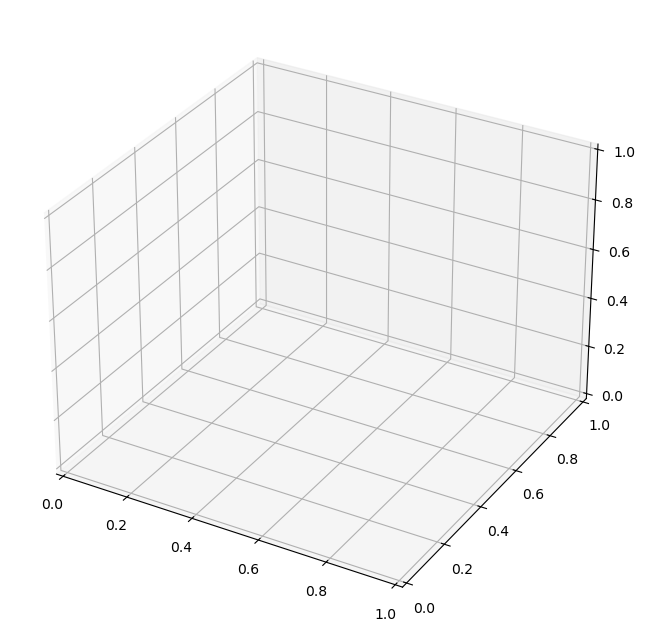

In [4]:
# Tworzenie wykresu
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Wykres orbity
ax.plot(positions[:, 0], positions[:, 1], positions[:, 2], label='Orbita satelity', color='red')

# Wykres Ziemi jako kula
R_EARTH = 6378.12  # km
u, v = np.linspace(0, 2 * np.pi, 100), np.linspace(0, np.pi, 100)
x = R_EARTH * np.outer(np.cos(u), np.sin(v))
y = R_EARTH * np.outer(np.sin(u), np.sin(v))
z = R_EARTH * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x, y, z, color='blue', alpha=0.2)

# Ustawienia osi
ax.set_title("Orbita satelity w 3D")
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.legend()
ax.set_box_aspect([1, 1, 0.7])  # Równe proporcje osi
plt.show()